# Semi-Supervised Classification with Graph Convolution Networks

* 사용 데이터 셋 : gemsec facebook dataset

## 1. Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.manifold import TSNE

In [2]:
def set_seed(seed=42):
    # 1. 파이썬 기본 랜덤 시드 고정
    random.seed(seed)
    
    # 2. 넘파이 시드 고정
    np.random.seed(seed)
    
    # 3. 파이토치 시드 고정 (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    
    # 4. CuDNN 결정론적 연산 설정 (속도는 약간 느려질 수 있으나 재현성 보장)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. OS 환경 변수 고정 (일부 라이브러리 영향)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Seed fixed to: {seed}")

# 실행
set_seed(42)

Seed fixed to: 42


## 2. Load Data

In [3]:
# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# 1. 클래스 매핑 (8개)
class_map = {
    'artist': 0, 'athletes': 1, 'company': 2, 'government': 3,
    'new_sites': 4, 'politician': 5, 'public_figure': 6, 'tvshow': 7
}

all_edge_list = []
node_to_label = {}

# 2. 각 파일 읽기
for class_name, class_idx in class_map.items():
    df = pd.read_csv(f'E:/Study/수업/대학원/4-2/다변수 네트워크/논문리뷰/gemsec_facebook_dataset/facebook_clean_data/{class_name}_edges.csv')
    
    # 간선 리스트 추가
    edges = torch.tensor(df[['node_1', 'node_2']].values, dtype=torch.long)
    all_edge_list.append(edges)
    
    # 노드 라벨 할당
    unique_nodes = np.unique(df.values)
    for node in unique_nodes:
        node_to_label[node] = class_idx


# 전체 에지 및 노드 수 파악
edge_index = torch.cat(all_edge_list, dim=0).t() # [2, E]
num_nodes = max(node_to_label.keys()) + 1


# 라벨 텐서 생성
y = torch.zeros(num_nodes, dtype=torch.long)
for node, label in node_to_label.items():
    y[node] = label

## 3. GCN 정규화 인접 행렬 (Sparse) 계산

In [5]:
# --- 1단계: adj_norm 생성 및 GPU 이동 ---
# A_tilde = A + I
loop_indices = torch.arange(0, num_nodes).unsqueeze(0).repeat(2, 1)
adj_indices = torch.cat([edge_index, loop_indices], dim=1)
adj_values = torch.ones(adj_indices.shape[1])

# Degree 계산 (D_tilde)
row_idx, col_idx = adj_indices
deg_temp = torch.zeros(num_nodes)
deg_temp.scatter_add_(0, row_idx, adj_values)

# D^-1/2 계산
deg_inv_sqrt = deg_temp.pow(-0.5)
deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.

# 정규화 연산 및 Sparse 텐서 생성
adj_values_norm = deg_inv_sqrt[row_idx] * adj_values * deg_inv_sqrt[col_idx]
# 생성 시점에 바로 .to(device)를 호출하여 GPU로 보냅니다.
adj_norm = torch.sparse_coo_tensor(adj_indices, adj_values_norm, (num_nodes, num_nodes)).to(device)

# --- 2단계: LDP (Local Degree Profile) 특징 생성 ---
# edge_index의 각 행을 GPU로 보냅니다.
row = edge_index[0].to(device)
col = edge_index[1].to(device)

# 1. 각 노드의 실제 degree 계산 (GPU 상에서 수행)
deg = torch.zeros(num_nodes).to(device)
deg.scatter_add_(0, row, torch.ones(row.size(0)).to(device))

# 2. 이웃의 degree 정보 취합 (SPMM 연산)
# 이제 adj_norm과 deg 모두 같은 device에 있으므로 에러가 발생하지 않습니다.
deg_neighbor_avg = torch.spmm(adj_norm, deg.unsqueeze(1)) 

# 3. 여러 통계량을 합쳐서 특징 행렬 구성 (Degree + Neighbor Average Degree)
# 두 텐서가 모두 GPU에 있으므로 concat 후 바로 사용 가능합니다.
features_raw = torch.cat([deg.unsqueeze(1), deg_neighbor_avg], dim=1)

# Linear 레이어를 통해 128차원으로 확장 (가중치도 GPU에 있어야 함)
projection = torch.nn.Linear(2, 128).to(device)
with torch.no_grad():
    features = projection(features_raw)

print(f"Features Device: {features.device}")
print(f"Adj_norm Device: {adj_norm.device}")

Features Device: cuda:0
Adj_norm Device: cuda:0


## 4. Model

In [6]:
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj_norm):
        # 1. Linear Transformation (X * W)
        # 만약 X가 Sparse라면 torch.spmm 사용, Dense라면 torch.mm 사용
        support = torch.mm(x, self.weight)
        
        # 2. Graph Aggregation (A_hat * support)
        # adj_norm은 무조건 Sparse이므로 torch.spmm 사용
        output = torch.spmm(adj_norm, support)
        return output

class GCN(nn.Module):
    def __init__(self, n_feat, n_hid, n_class, dropout):
        super(GCN, self).__init__()
        self.gc1 = GCNLayer(n_feat, n_hid)
        self.gc2 = GCNLayer(n_hid, n_class)
        self.dropout = dropout

    def forward(self, x, adj_norm):
        x = F.relu(self.gc1(x, adj_norm))
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.gc2(x, adj_norm)
        return F.log_softmax(x, dim=1)

## 5. Masking

In [7]:
# stratified : class 별로 샘플 갯수 차이가 크기때문에 과적합 현상이 발생
# 따라서 class 별로 동일한 갯수의 샘플 수를 뽑아 학습 진행

def create_fixed_sample_mask(y, num_nodes, samples_per_class=500):
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    for c in range(8): # 8개 카테고리
        # 해당 클래스의 전체 인덱스 추출
        class_indices = (y == c).nonzero(as_tuple=False).view(-1)
        
        # 셔플
        perm = torch.randperm(class_indices.size(0))
        class_indices = class_indices[perm]
        
        # 고정된 숫자만큼 할당
        n_train = min(samples_per_class, len(class_indices))
        n_val = min(samples_per_class, len(class_indices) - n_train)
        
        train_mask[class_indices[:n_train]] = True
        val_mask[class_indices[n_train:n_train + n_val]] = True
        
    # 나머지는 모두 테스트용
    test_mask = ~(train_mask | val_mask)
    
    return train_mask, val_mask, test_mask

# 클래스당 50개씩 샘플링 (총 400개 학습 데이터)
train_mask, val_mask, test_mask = create_fixed_sample_mask(y, num_nodes, samples_per_class=500)

print(f"Train nodes: {train_mask.sum().item()} (All classes balanced)")

Train nodes: 2000 (All classes balanced)


## 6. Train

In [8]:
# 데이터 이동 (라벨 및 인덱스)
y = y.to(device)

# Sparse 행렬도 .to(device)를 통해 GPU 메모리로 올릴 수 있습니다.
adj_norm = adj_norm.to(device)

model = GCN(n_feat=128, n_hid=32, n_class=8, dropout=0.5).to(device)

t-SNE 계산 중... 시간이 다소 소요될 수 있습니다.


C:\Users\Hong\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Hong\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Hong\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Hong\.conda\envs\yolov8\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Hong\.conda\envs\yolov

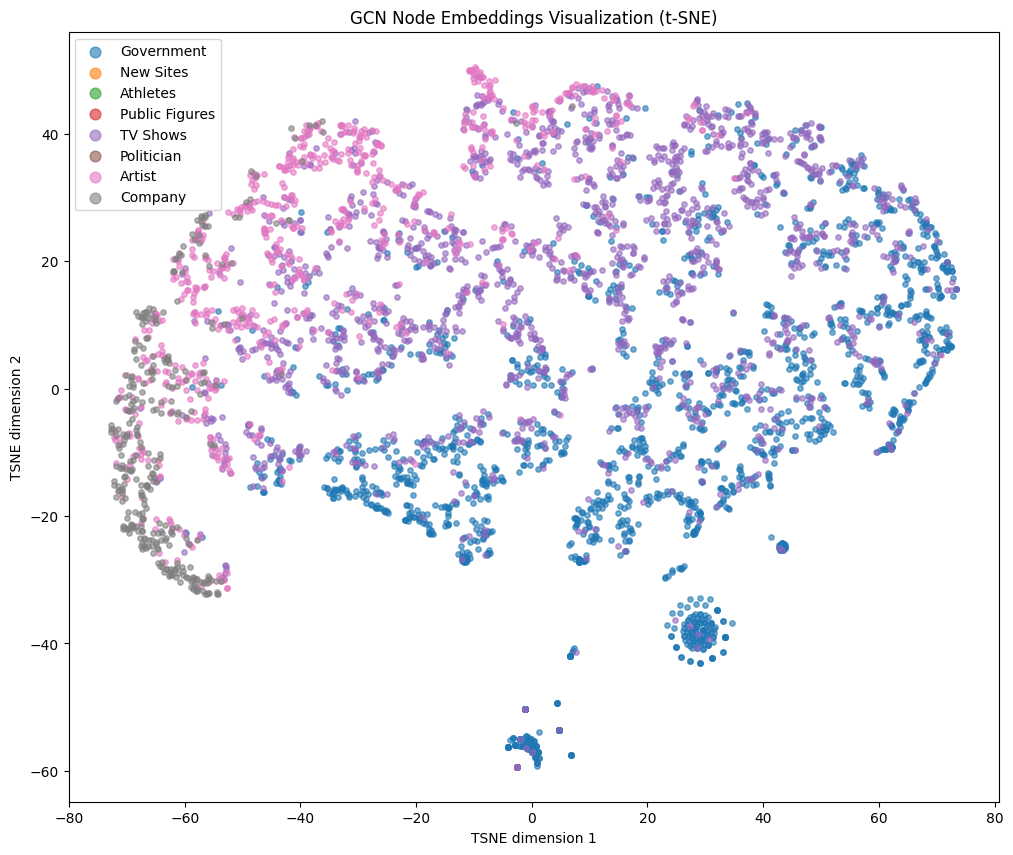

In [9]:
# 모델 로드 및 임베딩 추출
checkpoint = torch.load('E:/Study/수업/대학원/4-2/다변수 네트워크/논문리뷰/gemsec_facebook_dataset/weight3/gcn_weights_epoch_180.pth')
model.load_state_dict(checkpoint['model_state_dict']) # 딕셔너리 구조에서 모델 가중치만 추출하여 로드
model.eval()

with torch.no_grad():
    # GCN의 마지막 혹은 직전 레이어 결과물 (Logits 또는 Hidden state)
    # 여기서는 최종 결과인 logits를 사용하거나, 모델을 수정해 중간층을 뽑을 수 있습니다.
    out = model(features.to(device), adj_norm).to(device)
    embeddings = out.cpu().numpy() # [num_nodes, n_class]

# t-SNE를 이용한 차원 축소 (고차원 -> 2차원)
test_indices = torch.where(test_mask)[0].cpu().numpy()
sample_size = 5000
actual_sample_size = min(sample_size, len(test_indices))
chosen_test_indices = np.random.choice(test_indices, actual_sample_size, replace=False)
sampled_embeddings = embeddings[chosen_test_indices]
sampled_labels = y[chosen_test_indices].cpu().numpy()

print("t-SNE 계산 중... 시간이 다소 소요될 수 있습니다.")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(sampled_embeddings)

# 4. 시각화
plt.figure(figsize=(12, 10))
target_names = ['Government', 'New Sites', 'Athletes', 'Public Figures', 
                'TV Shows', 'Politician', 'Artist', 'Company']

for i in range(8):
    # 각 클래스별로 점을 찍음
    mask = (sampled_labels == i)
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                label=target_names[i], alpha=0.6, s=15)

plt.legend(loc='best', markerscale=2)
plt.title('GCN Node Embeddings Visualization (t-SNE)')
plt.xlabel('TSNE dimension 1')
plt.ylabel('TSNE dimension 2')
plt.show()